#  __Лаба №2. Бинарная классификация (Titanic)__

## 0. Используем датасет [Titanic](https://www.kaggle.com/datasets/yasserh/titanic-dataset) (файл train.csv, целевой столбец Survived).

In [2]:
# !pip install kagglehub

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [5]:
files = os.listdir(path)
files

['Titanic-Dataset.csv']

In [6]:
df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Подготовить данные: базовый анализ, обработка пропусков, разделение числовых и категориальных признаков.

- Сначала изучим наши данные

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
meanAge = np.mean(df['Age'].dropna().values)
medianAge = np.quantile(df['Age'].dropna().values, q=0.5)
print(f'Среднее: {meanAge} Медиана: {medianAge}')


Среднее: 29.69911764705882 Медиана: 28.0


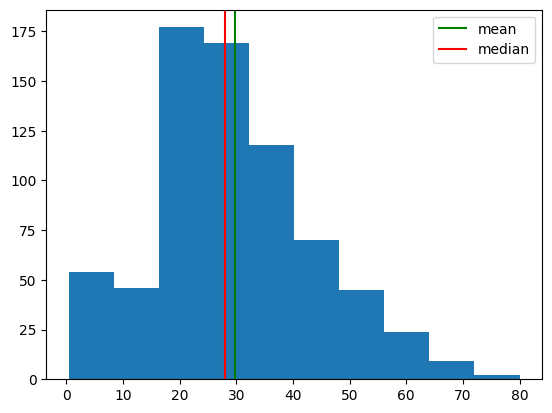

In [10]:
plt.hist(df['Age'])

plt.axvline(x=meanAge, color='g', label='mean')
plt.axvline(x=medianAge, color='r', label='median')

plt.legend()
plt.show()

- Попробуем заполнить возраст медианной

In [11]:
df['Age'].fillna(medianAge, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_15608\1273055375.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(medianAge, inplace=True)


In [12]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- Из колонок 'Cabin' и 'Ticket' мне кажется ничего полезного не получится извлечь

In [13]:
df = df.drop(['Cabin', 'Ticket'], axis=1)


In [14]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [15]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       2
dtype: int64

- Также у нас есть пропуски в столбце Embarked. Их всего два, на всякий случай посмотрим что в них

In [16]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,80.0,NaN


- Мое мнение лучше удалить эти данные, и пропусков после этого не будет совсем. И переименуем индексы 

In [17]:
df = df.dropna()
df = df.reset_index(drop=True)

In [18]:
# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [19]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

- Я хочу заменить ненужную информацию в столбце Name. Титул людей весьма важная вещь, поэтому ее оставим. Применим регуляркм:

In [20]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [21]:
pd.crosstab(df['Title'], df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [22]:
df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Countess,1.000000
3,Don,0.000000
4,Dr,0.428571
5,Jonkheer,0.000000
6,Lady,1.000000
7,Major,0.500000
8,Master,0.575000
9,Miss,0.696133


In [23]:
df = df.drop(['Name'], axis=1)

In [24]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,8.0500,S,Mr


In [25]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,male,27.0,0,0,13.0000,S,Rev
885,888,1,1,female,19.0,0,0,30.0000,S,Miss
886,889,0,3,female,28.0,1,2,23.4500,S,Miss
887,890,1,1,male,26.0,0,0,30.0000,C,Mr


- я не хочу использовать OneHotEncoder для столбца Title, так как там много разных титулов мне кажется лучше всего подойдет LabelEncoder

In [26]:
from sklearn.preprocessing import LabelEncoder

categorical_features = ['Sex', 'Title']

for col in categorical_features:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [27]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,1,22.0,1,0,7.2500,S,12
1,2,1,1,0,38.0,1,0,71.2833,C,13
2,3,1,3,0,26.0,0,0,7.9250,S,9
3,4,1,1,0,35.0,1,0,53.1000,S,13
4,5,0,3,1,35.0,0,0,8.0500,S,12
...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,1,27.0,0,0,13.0000,S,15
885,888,1,1,0,19.0,0,0,30.0000,S,9
886,889,0,3,0,28.0,1,2,23.4500,S,9
887,890,1,1,1,26.0,0,0,30.0000,C,12


- а тут уже удобнее OneHotEncoder использовать 

In [28]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(df[['Embarked']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Embarked']))
encoded_df

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
884,0.0,0.0,1.0
885,0.0,0.0,1.0
886,0.0,0.0,1.0
887,1.0,0.0,0.0


In [29]:
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

- итого, после всех преобразований, получилось это:

In [30]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,12,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,71.2833,13,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,7.9250,9,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,53.1000,13,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,8.0500,12,0.0,0.0,1.0


## 2. Обучить LogisticRegression (можно Линейная регрессия, Случаный лес регрессор, Градиентный Бустинг).

- Используем столбец Survived как целевую переменную

In [31]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((711, 11), (178, 11))

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### LogisticRegression

In [34]:
baseline_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("logreg", LogisticRegression(max_iter=500, random_state=42))
])
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

### RandomForest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

### GradientBoosting

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=55, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

## 3. Оценить качество: Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix, ROC-кривая.

### Посмотрим на результаты метрик(acc, precision, recall, f1, roc_auc):

#### LogisticRegression

In [37]:
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

acc, precision, recall, f1, roc_auc

(0.8033707865168539,
 0.7796610169491526,
 0.6764705882352942,
 0.7244094488188977,
 0.8479946524064171)

#### RandomForest

In [38]:
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)


acc_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf

(0.7921348314606742,
 0.7540983606557377,
 0.6764705882352942,
 0.7131782945736435,
 0.8106283422459893)

#### GradientBoosting

In [39]:
acc_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)


acc_gb, precision_gb, recall_gb, f1_gb, roc_auc_gb

(0.8426966292134831,
 0.8571428571428571,
 0.7058823529411765,
 0.7741935483870968,
 0.830548128342246)

### Посмотрим confusion matrix и ROC-кривую

#### LogisticRegression

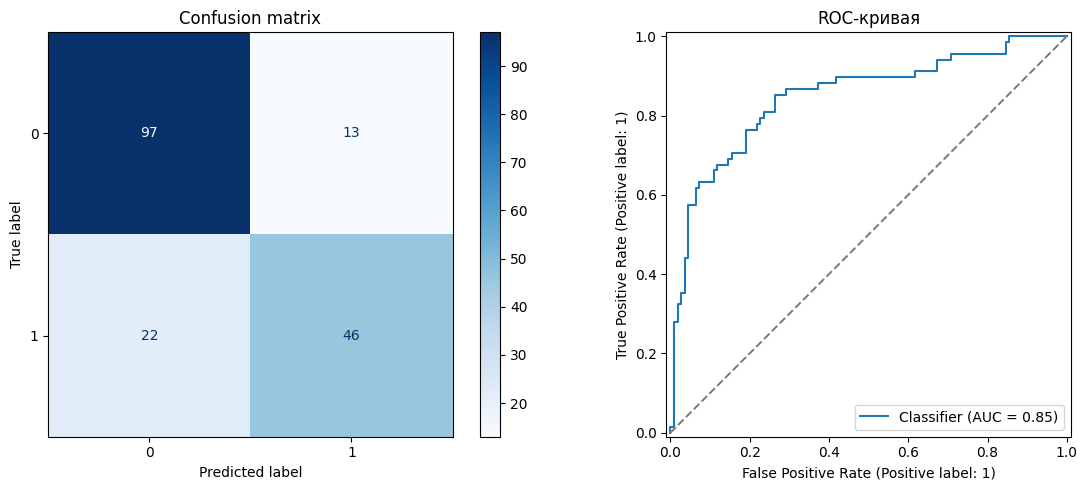

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

#### LogisticRegression

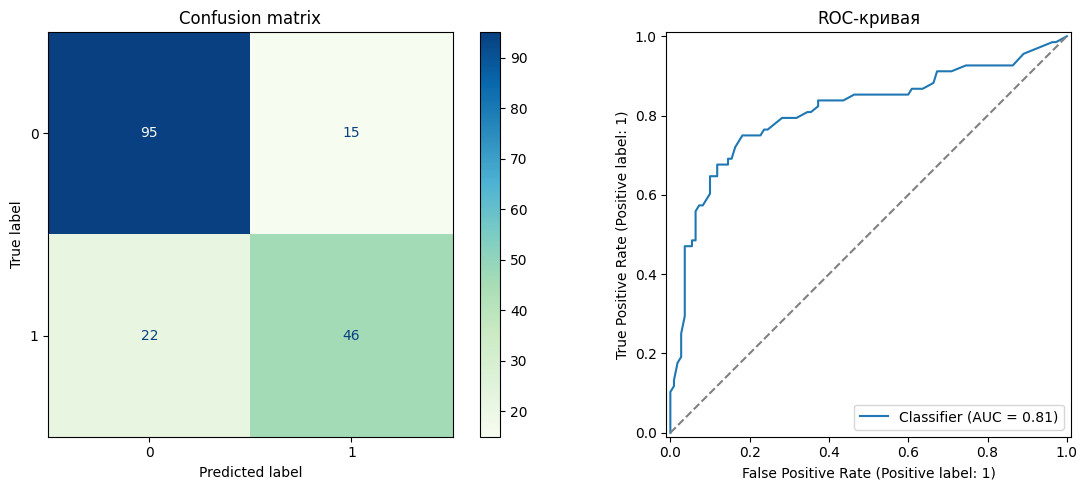

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], cmap="GnBu")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

#### GradientBoosting

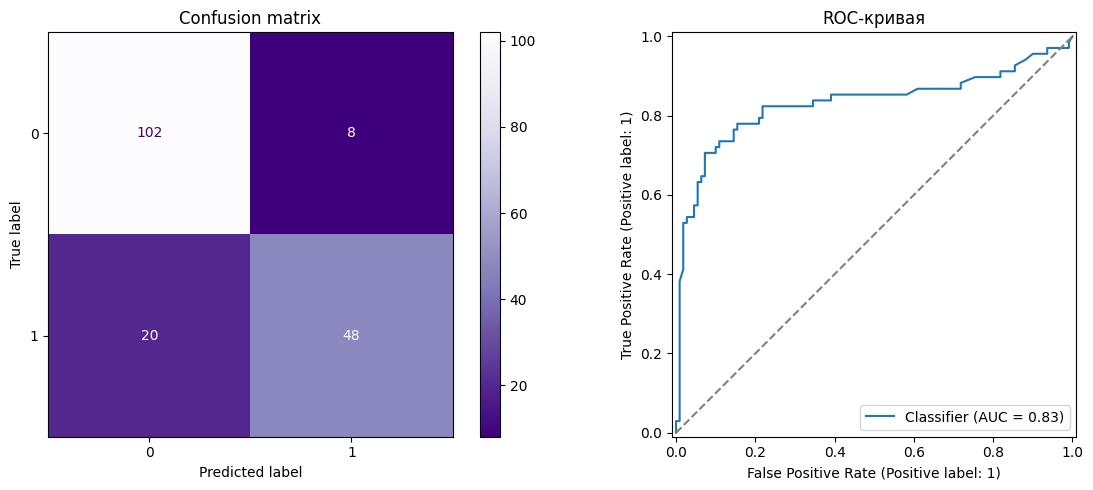

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, ax=axes[0], cmap="Purples_r")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba_gb, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

## 4. Показать влияние порога (например, 0.2/0.5/0.8) на precision/recall/F1 и сделать вывод по выбору порога.

Тааааааааааак, краткое повторение для себя: 
- TN (True Negative)  | в нашем случае правильное предсказание того, что человек не выжил на Титанике
- FN (False Negative) | в нашем случае неправильное предсказание того, что человек не выжил на Титанике
- TP (True Positive)  | в нашем случае правильное предсказание того, что человек выжил на Титанике
- FP (False Positive) | в нашем случае неправильное предсказание того, что человек выжил на Титанике

Метрики и как они подсчитываются: 

$Precision = \frac{TP}{TP + FP}$ - из всех пассажиров, которых предсказали как выжившие, сколько действительно выжили

$Recall = \frac{TP}{TP + FN}$ - из всех пассажиров, которые действительно выжили, сколько правильно предсказали


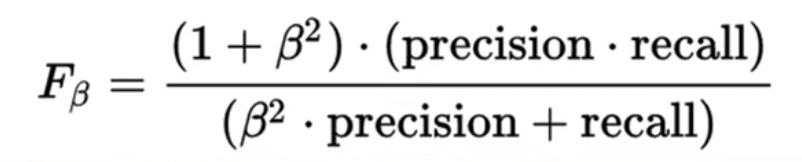

В последней метрике оказывается гиперпараметр неограничивается единицей, мы можем с помощью бетта задать больший вес precision или recall. То есть, если нам важна метрика precision(например), то мы можем дать ей дополнительный вес, чтобы лучше отслеживать итоговое значение.

В общем и целом, F1 баланс между ошибками

#### LogisticRegression

In [43]:
thresholds = np.linspace(0.1, 0.9, 9)

rows_logreg = []
for thr in thresholds:
    y_thr = (y_proba >= thr).astype(int)
    rows_logreg.append({
        "threshold": round(thr, 2),
        "precision": precision_score(y_test, y_thr, zero_division=0),
        "recall": recall_score(y_test, y_thr, zero_division=0),
        "f1": f1_score(y_test, y_thr, zero_division=0)
    })

df_logreg = pd.DataFrame(rows_logreg)

df_logreg

,threshold,precision,recall,f1
0,0.1,0.433333,0.955882,0.596330
1,0.2,0.594059,0.882353,0.710059
2,0.3,0.659091,0.852941,0.743590
3,0.4,0.695652,0.705882,0.700730
4,0.5,0.779661,0.676471,0.724409
5,0.6,0.840000,0.617647,0.711864
6,0.7,0.868421,0.485294,0.622642
7,0.8,0.904762,0.279412,0.426966
8,0.9,0.800000,0.058824,0.109589


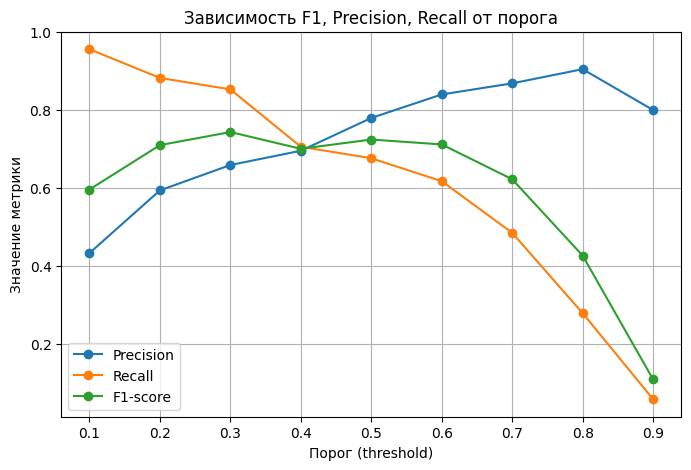

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(df_logreg['threshold'], df_logreg['precision'], '-o', label='Precision')
plt.plot(df_logreg['threshold'], df_logreg['recall'], '-o', label='Recall')
plt.plot(df_logreg['threshold'], df_logreg['f1'], '-o', label='F1-score')
plt.xlabel('Порог (threshold)')
plt.ylabel('Значение метрики')
plt.title('Зависимость F1, Precision, Recall от порога')
plt.legend()
plt.grid(True)
plt.show()

#### RandomForest

In [45]:
rows_rf = []
for thr in thresholds:
    y_thr = (y_proba_rf >= thr).astype(int)
    rows_rf.append({
        "threshold": round(thr, 2),
        "precision": precision_score(y_test, y_thr, zero_division=0),
        "recall": recall_score(y_test, y_thr, zero_division=0),
        "f1": f1_score(y_test, y_thr, zero_division=0),
    })

df_rf = pd.DataFrame(rows_rf)

df_rf

,threshold,precision,recall,f1
0,0.1,0.455882,0.911765,0.607843
1,0.2,0.517857,0.852941,0.644444
2,0.3,0.591398,0.808824,0.683230
3,0.4,0.698630,0.750000,0.723404
4,0.5,0.741935,0.676471,0.707692
5,0.6,0.785714,0.647059,0.709677
6,0.7,0.844444,0.558824,0.672566
7,0.8,0.842105,0.470588,0.603774
8,0.9,0.833333,0.220588,0.348837


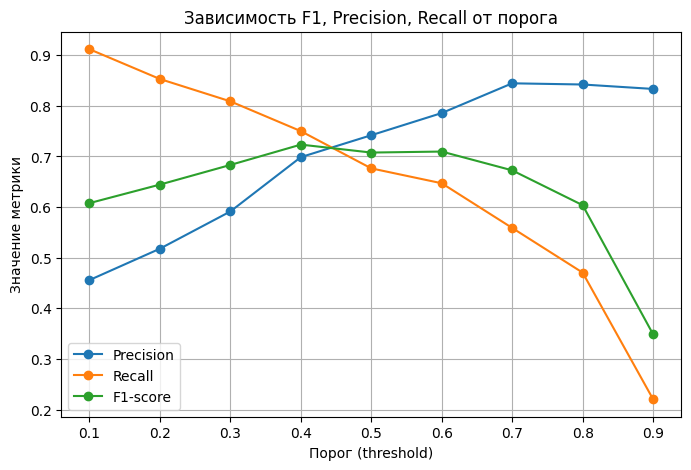

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(df_rf['threshold'], df_rf['precision'], '-o', label='Precision')
plt.plot(df_rf['threshold'], df_rf['recall'], '-o', label='Recall')
plt.plot(df_rf['threshold'], df_rf['f1'], '-o', label='F1-score')
plt.xlabel('Порог (threshold)')
plt.ylabel('Значение метрики')
plt.title('Зависимость F1, Precision, Recall от порога')
plt.legend()
plt.grid(True)
plt.show()

#### GradientBoosting

In [47]:
rows_gb = []
for thr in thresholds:
    y_thr = (y_proba_gb >= thr).astype(int)
    rows_gb.append({
        "threshold": round(thr, 2),
        "precision": precision_score(y_test, y_thr, zero_division=0),
        "recall": recall_score(y_test, y_thr, zero_division=0),
        "f1": f1_score(y_test, y_thr, zero_division=0),
    })

df_gb = pd.DataFrame(rows_gb)

df_gb

,threshold,precision,recall,f1
0,0.1,0.401274,0.926471,0.560000
1,0.2,0.615385,0.823529,0.704403
2,0.3,0.682927,0.823529,0.746667
3,0.4,0.726027,0.779412,0.751773
4,0.5,0.857143,0.705882,0.774194
5,0.6,0.862745,0.647059,0.739496
6,0.7,0.886364,0.573529,0.696429
7,0.8,0.944444,0.500000,0.653846
8,0.9,0.937500,0.220588,0.357143


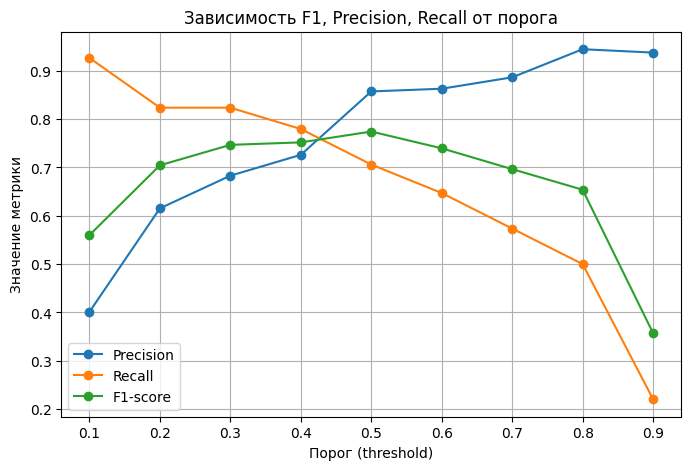

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(df_gb['threshold'], df_gb['precision'], '-o', label='Precision')
plt.plot(df_gb['threshold'], df_gb['recall'], '-o', label='Recall')
plt.plot(df_gb['threshold'], df_gb['f1'], '-o', label='F1-score')
plt.xlabel('Порог (threshold)')
plt.ylabel('Значение метрики')
plt.title('Зависимость F1, Precision, Recall от порога')
plt.legend()
plt.grid(True)
plt.show()

## 5. Итоги второй лабораторной

Оптимальный и итоговый результат у нас получается с порогом __0.5 в GradientBoosting__. F1 равна __0.774194__, то есть это самая высшая оценка баланса между Recall и Precision.

Также мы можем заметить, что при низких порогах(менее 0.4) precision намного меньше recall, обратная ситуация происходит, если порог больше 0.6. 

---

# __Лаба №3. Оптимизация гиперпараметров__

Берём модель из ЛР2 (Titanic)

## 1. Настроить гиперпараметры через RandomizedSearchCV (≥15 итераций)

В прошлой лабе я уже сам менял параметр в градиентном бустинге (получилось n_estimators=55), но RandomizedSearchCV позволит подобрать не только этот параметр, но и многие другие, и тем самым должен улучшить наши предсказания. 

In [49]:
from sklearn.model_selection import RandomizedSearchCV

#### LogisticRegression

In [50]:
param_distributions = {
    "logreg__C": np.logspace(-3, 2, 30),
    "logreg__penalty": ["l1", "l2"],
    "logreg__solver": ["liblinear", "saga"],
}

search = RandomizedSearchCV(
    baseline_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=6,
    n_jobs=-1,
    random_state=42,
)
search.fit(X_train, y_train)

best_params_logreg_f1 = search.best_params_
best_score_logreg_f1 = search.best_score_

search.best_params_, search.best_score_

({'logreg__solver': 'liblinear',
  'logreg__penalty': 'l1',
  'logreg__C': 0.5736152510448681},
 0.7258194316251338)

#### GradientBoosting

In [51]:
param_distributions_gb = {
    "n_estimators": [30, 50, 55, 100, 150, 175, 200, 250, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [3, 4, 5, 7, 9]
}

In [59]:
search_gb_f1 = RandomizedSearchCV(
    gb_model,
    param_distributions=param_distributions_gb,
    n_iter=50,
    scoring="f1",
    cv=6,
    n_jobs=-1,
    random_state=42
)
search_gb_f1.fit(X_train, y_train)
best_params_gb_f1 = search_gb_f1.best_params_
best_score_gb_f1 = search_gb_f1.best_score_

print("Градиентный бустинг:")
print("Лучшие параметры:", best_params_gb_f1)
print("Лучший средний F1 на кросс-валидации:", best_score_gb_f1)

Градиентный бустинг:
Лучшие параметры: {'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.2}
Лучший средний F1 на кросс-валидации: 0.7745218913908772


In [ ]:
search_gb_roc = RandomizedSearchCV(
    gb_model,
    param_distributions=param_distributions_gb,
    n_iter=50,
    scoring="roc_auc",
    cv=6,
    n_jobs=-1,
    random_state=42
)
search_gb_roc.fit(X_train, y_train)
best_params_gb_roc = search_gb_roc.best_params_
best_score_gb_roc = search_gb_roc.best_score_

print("Градиентный бустинг:")
print("Лучшие параметры:", best_params_gb_roc)
print("Лучший средний roc_auc на кросс-валидации:", best_score_gb_roc)

Градиентный спуск:
Лучшие параметры: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.01}
Лучший средний roc_auc на кросс-валидации: 0.8755760376218983


#### RandomForest

In [54]:
param_distributions_rf = {
    'n_estimators': [50, 55, 75, 100, 125, 130, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [55]:
search_rf_f1 = RandomizedSearchCV(
    rf_model,
    param_distributions=param_distributions_rf,
    n_iter=50,
    scoring="f1",
    cv=6,
    n_jobs=-1,
    random_state=42
)
search_rf_f1.fit(X_train, y_train)
best_params_rf_f1 = search_rf_f1.best_params_
best_score_rf_f1 = search_rf_f1.best_score_

print("Случайные леса:")
print("Лучшие параметры:", best_params_rf_f1)
print("Лучший средний F1 на кросс-валидации:", best_score_rf_f1)

Случайные леса:
Лучшие параметры: {'n_estimators': 130, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Лучший средний F1 на кросс-валидации: 0.7899044330259158


In [56]:
search_rf_roc = RandomizedSearchCV(
    rf_model,
    param_distributions=param_distributions_rf,
    n_iter=50,
    scoring="roc_auc",
    cv=6,
    n_jobs=-1,
    random_state=42
)
search_rf_roc.fit(X_train, y_train)
best_params_rf_roc = search_rf_roc.best_params_
best_score_rf_roc = search_rf_roc.best_score_

print("Случайные леса:")
print("Лучшие параметры:", best_params_rf_roc)
print("Лучший средний roc_auc на кросс-валидации:", best_score_rf_roc)

Случайные леса:
Лучшие параметры: {'n_estimators': 55, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30, 'bootstrap': True}
Лучший средний roc_auc на кросс-валидации: 0.8817099708404057


## 2. Сравнить метрики «до/после»

- Самые большие изменения произошли в RandomForest, поэтому о нем и поговорим

In [57]:
results = {
    "Model": ["RandomForest (ROC-AUC)", "RandomForest (F1)"],
    "Best Score": [best_score_rf_roc, best_score_rf_f1],
    "Baseline": [roc_auc_rf, f1_rf]
}

df_results = pd.DataFrame(results)
df_results

,Model,Best Score,Baseline
0,RandomForest (ROC-AUC),0.881710,0.810628
1,RandomForest (F1),0.789904,0.713178


Как видим результаты стали намного лучше!!! RandomizedSearchCV сильно улучшил качество.

Какие, по моему мнению, этому объяснения:
- Cтандартные параметры не подходят к нашим данным.
- RandomizedSearchCV изменил нам параметры, которые я нашел на [сайте](https://habr.com/ru/companies/otus/articles/754402/).
- Tакже этому помогла кросс-валидация(мы проверили модель на разных подмножествах данных). В нашем случае мы разделили на 6 частей наши данные и по одному разу каждая часть была тестовой. Таким образом, мы убеждаемся, что модель дала не случайный ответ.

__Поэтому следует оставить найденные настройки.__

Я уверен, что обработать данные можно намного лучше, чем у меня, но лаба заточена под другое, так что надеюсь я всё правильно реализовал.